<a href="https://colab.research.google.com/github/jennifer-algabre/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [7]:
!git clone https://github.com/jennifer-algabre/flyrank-ml-internship.git
%cd flyrank-ml-internship

import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

Cloning into 'flyrank-ml-internship'...
remote: Enumerating objects: 163, done.
remote: Counting objects: 100% (163/163), done.
remote: Compressing objects: 100% (134/134), done.
remote: Total 163 (delta 70), reused 77 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (163/163), 2.01 MiB | 8.39 MiB/s, done.
Resolving deltas: 100% (70/70), done.
/content/flyrank-ml-internship/flyrank-ml-internship


In [8]:
df["label"] = (df["trend_direction"] == "down").astype(int)

df["has_word_count"] = df["word_count"].notna().astype(int)
df["has_content_age"] = df["content_age_days"].notna().astype(int)

df["avg_position"] = df["avg_position"].replace(0, np.nan)

features = [
    "impressions_90d",
    "clicks_90d",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "word_count",
    "content_age_days",
    "days_since_last_update",
    "search_volume",
    "competition"
]

X = df[features].copy()

for col in X.columns:
    X[col] = X[col].fillna(X[col].median())

X["has_word_count"] = df["has_word_count"]
X["has_content_age"] = df["has_content_age"]

y = df["label"]

In [9]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X, y)

df["decline_probability"] = model.predict_proba(X)[:,1]

## 1. Ranked actions + reason codes

The model is used to create a ranked content review queue rather than making automatic publishing decisions.

Pages with a higher predicted probability of decline are reviewed first because they may benefit most from a content refresh.

Each recommendation includes a simple reason code based on observable search performance signals so that reviewers understand why the page appears in the queue.

In [10]:
conditions = [
    df["ctr"] < 1,
    df["avg_position"] > 20,
    df["engagement_rate"] < 2,
    df["days_since_last_update"] > 365
]

choices = [
    "Low CTR",
    "Low Search Ranking",
    "Low Engagement",
    "Content Outdated"
]

df["reason_code"] = np.select(
    conditions,
    choices,
    default="General Review"
)

queue = df[[
    "content_id",
    "decline_probability",
    "reason_code"
]].sort_values(
    "decline_probability",
    ascending=False
)

queue.head(20)

,content_id,decline_probability,reason_code
16205,content_00d3b68b4fa7,1.0,Low CTR
4783,content_fab24ca59480,1.0,Low CTR
12092,content_e1039a455c32,1.0,Low CTR
9634,content_86444e331502,1.0,Low CTR
24008,content_1e4395ce2dc8,1.0,Low CTR
2285,content_f81c38418a78,1.0,Low CTR
16074,content_673fe764797f,1.0,Low CTR
21344,content_af3e1659ba29,1.0,Low CTR
19347,content_b01a3c1455db,1.0,Low CTR
19103,content_c4169a67abbd,1.0,Low CTR


## 2. Intended use and limits

This playbook is intended to support SEO analysts and content teams when prioritizing pages for review.

The recommendations are based on observed search performance signals and should be interpreted as decision support rather than automated decisions.

The model cannot determine the true cause of declining performance because external factors such as competitor activity, algorithm updates, seasonality, and business strategy are not represented in the dataset.

## 3. Human review + the no-go list

Every recommendation should be reviewed by a human before any content changes are made.

A reviewer should confirm:

• the page is still relevant to current business goals

• the content is factually accurate

• search intent has not changed

• seasonal effects are considered

The following actions should never be automated:

• publishing rewritten content

• deleting pages

• changing page titles

• changing structured data

• making SEO decisions based only on the model score

## 4. Monitoring / retrain triggers

The model should be monitored periodically to ensure that its recommendations remain useful.

Possible retraining triggers include:

• changes in click-through rate distributions

• shifts in average search position

• major search engine algorithm updates

• declining model performance during validation

Retraining should only occur after reviewing new data quality and confirming that feature definitions remain consistent.

In [11]:
import os

os.makedirs("work/outputs", exist_ok=True)

queue.to_csv(
    "work/outputs/content_action_queue.csv",
    index=False
)

print("Queue exported.")

Queue exported.


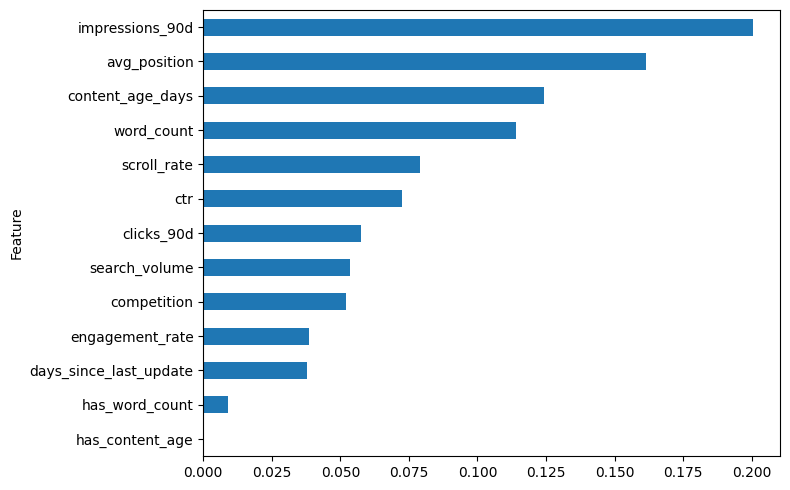

In [12]:
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

os.makedirs("work/figures", exist_ok=True)

importance.plot.barh(
    x="Feature",
    y="Importance",
    figsize=(8,5),
    legend=False
)

plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    "work/figures/feature_importance.png",
    dpi=300
)

plt.show()

## 5. Exports for the paper

The notebook exports a ranked content review queue to **work/outputs/** and saves the feature importance visualization to **work/figures/**.

These exported files provide traceable artifacts that can be reused in the final capstone paper while keeping the workflow reproducible.